# OASIS → AnnData

The OASIS screen as run at the `axiom` site ([`cpg0037`](https://broadinstitute.github.io/cellpainting-gallery/)), 22,042 wells over five batches. The other sources (`xellar`, `insphero`, `hepatopac`) publish no feature-selected profiles. 299 wells repeat the same batch, plate and well identifier, so the default index is kept.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0037-oasis/axiom/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0037-oasis/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
print(f"{len(files)} plates")

70 plates


In [3]:
adata = cpio.read_profiles(files, path_columns={"batch": 2}, on_column_mismatch="intersect")
adata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 22042 × 155
    obs: 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_Cytoplasm', 'Count_Nuclei', 'Object_Count', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


for column in present(["batch", "Plate"]):
    adata.obs[column] = adata.obs[column].astype("category")
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
Cells_AreaShape_Orientation,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_1_1,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_2_0,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_2_2,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_Correlation_Brightfield_5_00_256,nuclei,texture,brightfield,NaN,1
Nuclei_Texture_Correlation_Brightfield_5_01_256,nuclei,texture,brightfield,NaN,1
Nuclei_Texture_Correlation_Brightfield_5_03_256,nuclei,texture,brightfield,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["batch"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

22,042 wells x 155 features
non-finite: 0 | max|x|: 1065.3

batch:
batch
prod_26                              6384
prod_27                              6320
prod_25                              5570
prod_30                              3576
2026_04_13_OASIS_HepatoPAC_Batch1     192


In [6]:
adata.write_h5ad(PROFILES.parent / "oasis.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["batch", "Plate", "Site_Count"]))

,observed,baseline,ratio
covariate,,,
batch,0.302,0.256,1.176
Plate,0.042,0.016,2.648
Site_Count,0.945,0.916,1.031


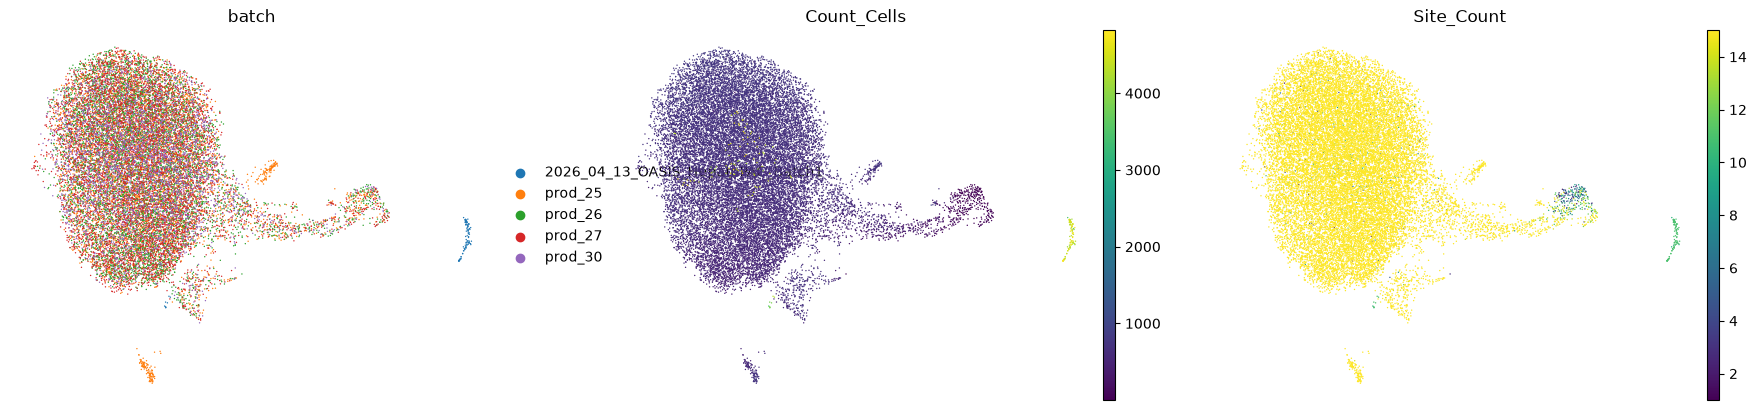

In [9]:
colours = present(["batch", "Count_Cells", "Site_Count"])[:3] or None
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=4)